In [1]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt


In [2]:
# Load dataset (Ensure correct file path)
dataset = pd.read_csv("Churn_Modelling.csv")

# Display first 5 rows
dataset.head(5)


,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [3]:
# Drop unnecessary columns
dataset.drop(columns=['RowNumber', 'CustomerId', 'Geography', 'Surname', 'Gender'], inplace=True)

# Display dataset after modifications
dataset.head(5)


,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,619,42,2,0.00,1,1,1,101348.88,1
1,608,41,1,83807.86,1,0,1,112542.58,0
2,502,42,8,159660.80,3,1,0,113931.57,1
3,699,39,1,0.00,2,0,0,93826.63,0
4,850,43,2,125510.82,1,1,1,79084.10,0


In [4]:
# Check for missing values
dataset.isnull().sum()


CreditScore        0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64

In [5]:
# Separate features (input) and target (output)
input_data = dataset.iloc[:, :-1]
output_data = dataset.iloc[:, -1]


In [6]:
# Standardize input features
ss = StandardScaler()
input_data = pd.DataFrame(ss.fit_transform(input_data), columns=input_data.columns)

# Display input data shape
input_data.shape


(10000, 8)

In [7]:
# Splitting data into train and test sets
x_train, x_test, y_train, y_test = train_test_split(input_data, output_data, test_size=0.2, random_state=42)

# Display training data shape
x_train.shape


(8000, 8)

In [8]:
!pip install tensorflow


In [9]:
import tensorflow
from keras.layers import Dense, BatchNormalization, Dropout
from keras.regularizers import L2
from keras.callbacks import EarlyStopping
from keras.models import Sequential


In [10]:
# Initialize model
ann = Sequential()

# Add layers
ann.add(Dense(6, input_dim=8, activation="relu", kernel_regularizer=L2(l2=0.01)))
ann.add(BatchNormalization())
ann.add(Dense(5, activation="relu", kernel_regularizer=L2(l2=0.01)))
ann.add(BatchNormalization())
ann.add(Dense(4, activation="relu", kernel_regularizer=L2(l2=0.01)))
ann.add(BatchNormalization())
ann.add(Dense(3, activation="relu", kernel_regularizer=L2(l2=0.01)))
ann.add(BatchNormalization())
ann.add(Dense(2, activation="relu", kernel_regularizer=L2(l2=0.01)))
ann.add(BatchNormalization())
ann.add(Dense(1, activation="sigmoid"))

# Compile the model
ann.compile(optimizer='adam', loss="binary_crossentropy", metrics=['accuracy'])


D:\anaconda\Lib\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [11]:
# Train ANN model with early stopping
ann.fit(x_train, y_train, batch_size=100, epochs=30, validation_data=(x_test, y_test), callbacks=EarlyStopping())


Epoch 1/30
80/80 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.4748 - loss: 0.9018 - val_accuracy: 0.8035 - val_loss: 0.8421
Epoch 2/30
80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5931 - loss: 0.8252 - val_accuracy: 0.8035 - val_loss: 0.7838
Epoch 3/30
80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7511 - loss: 0.7589 - val_accuracy: 0.8040 - val_loss: 0.7172
Epoch 4/30
80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7804 - loss: 0.6960 - val_accuracy: 0.8070 - val_loss: 0.6619
Epoch 5/30
80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7905 - loss: 0.6408 - val_accuracy: 0.8085 - val_loss: 0.6047
Epoch 6/30
80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8001 - loss: 0.5963 - val_accuracy: 0.8190 - val_loss: 0.5578
Epoch 7/30
80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8049 - loss: 0.5583 - val_accuracy: 0.8300 - val_loss: 0.5122
Epoch 8/30
80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8199 - loss: 0.5212 - val_accuracy: 0.8365 - val_loss:

In [12]:
# Predict on test data
prd = ann.predict(x_test)


63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step


In [13]:
# Convert predicted values to 0 or 1 for test set
prd_data = [1 if i[0] > 0.5 else 0 for i in prd]


In [14]:
# Predict on training data
prd1 = ann.predict(x_train)

# Convert predicted values to 0 or 1 for train set
prd_data1 = [1 if i[0] > 0.5 else 0 for i in prd1]


250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 911us/step


In [15]:
from sklearn.metrics import accuracy_score

# Compute accuracy for train and test sets
train_accuracy = accuracy_score(y_train, prd_data1) * 100
test_accuracy = accuracy_score(y_test, prd_data) * 100

print(f"Train Accuracy: {train_accuracy:.2f}%, Test Accuracy: {test_accuracy:.2f}%")


Train Accuracy: 85.34%, Test Accuracy: 85.65%


In [16]:
# Define custom input data
input_data = np.array([[-0.564197, -0.660018, -0.695982, 0.324119, 
                        0.807737, -1.547768, -1.030670, -1.013811]])

# Predict using trained model
prd = ann.predict(input_data)

# Process predictions
prd_data = [1 if i[0] > 0.5 else 0 for i in prd]

print(f"Predicted Class: {prd_data}")


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
Predicted Class: [0]


In [17]:
train_accuracy = ann.history.history['accuracy']
test_accuracy = ann.history.history['val_accuracy']


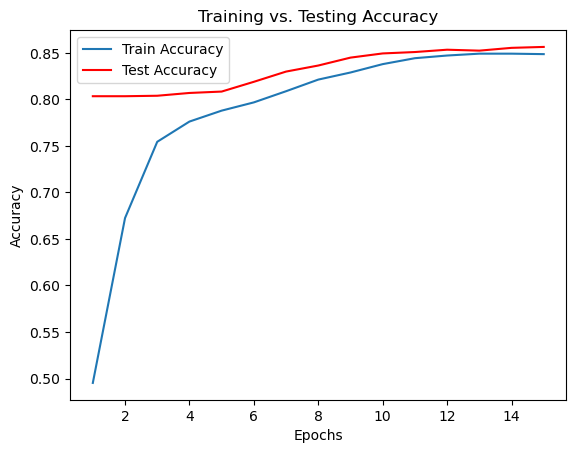

In [18]:
import matplotlib.pyplot as plt

# Get the number of epochs
epochs = range(1, len(train_accuracy) + 1)

# Plot accuracy
plt.plot(epochs, train_accuracy, label="Train Accuracy")
plt.plot(epochs, test_accuracy, color='red', label="Test Accuracy")

# Add labels and legend
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.title("Training vs. Testing Accuracy")
plt.legend()
plt.show()
